In [303]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Initial information

Country: Spain

Year: 2011

Technologies:
    - Solar
    - Wind
    - CCGT (gas turbine)
    - Coal
    - Hydro (battery)

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0). 

This database compiles assumptions and projections for a wide range of energy system technologies for different years. The data can be imported into Python and loaded into a pandas.DataFrame. 

In [304]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [305]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)

In [306]:
#calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [307]:
#calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

In [308]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [309]:
#calculate capital cost
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [310]:
technologies = ["onwind", "solar", "CCGT", "coal"]

data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)

cost_table

,Capital cost (EUR/MW/a),Marginal cost (EUR/MWh)
onwind,101644.123324,1.428600
solar,51346.829820,0.010600
CCGT,104788.020783,46.803121
coal,337208.027448,30.098840


## Data
For this project, time series data are required for the wind and solar capacity factors, as well as for electricity demand. The datasets used include:

    - Time series of wind capacity factors for European countries;
    - Time series of solar capacity factors for European countries;
    - Electricity demand time series

In [311]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

In [312]:
data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [313]:
# For this project the chosen country was Spain
country = 'ESP'

## Joint capacity and dispatch optimization

In [314]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

In [315]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green"], # colors that represent each carrier
)

In [316]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

<Axes: xlabel='snapshot', ylabel='MW'>

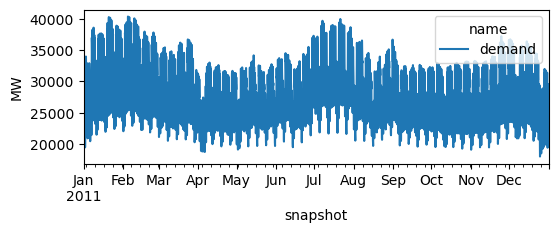

In [317]:
#create a plot with the hourly demand in 2011
n.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

In [318]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    #p_nom=25300, #25.3GW
    p_nom_extendable=True,
    p_nom_max=25300,
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    #p_nom=11700, #11.7GW
    p_nom_extendable=True,
    p_nom_max=11700,
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        #p_nom=21100, #21.1GW
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

<Axes: xlabel='snapshot', ylabel='CF'>

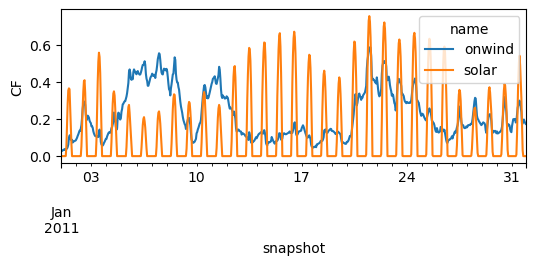

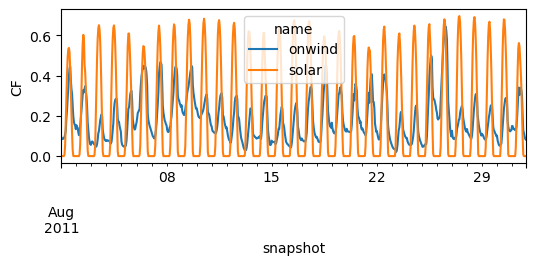

In [319]:
# capacity factors of wind and solar during January 2011 (winter)
n.generators_t.p_max_pu.loc["2011-01"].plot(figsize=(6, 2), ylabel="CF") 

# capacity factors of wind and solar during August 2011 (winter)
n.generators_t.p_max_pu.loc["2011-08"].plot(figsize=(6, 2), ylabel="CF") 

In [320]:
for df in [n.buses, n.loads, n.generators]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n.buses.index = pd.Index(n.buses.index.tolist(), dtype=object)
n.loads.index = pd.Index(n.loads.index.tolist(), dtype=object)
n.generators.index = pd.Index(n.generators.index.tolist(), dtype=object)

n.buses.index.name = "name"
n.loads.index.name = "name"
n.generators.index.name = "name"

## Model PyPSA

In [321]:
n.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 124.78it/s]
INFO:linopy.io: Writing time: 0.28s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78846 duals
Objective: 1.85e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [322]:
# how much capacity the model decided to build (optimised capacities in GW)
n.generators.p_nom_opt.div(1e3)

name
CCGT      25.300000
coal      11.700000
onwind    75.209302
solar      2.096247
Name: p_nom_opt, dtype: float64

In [323]:
dispatch = n.generators_t.p

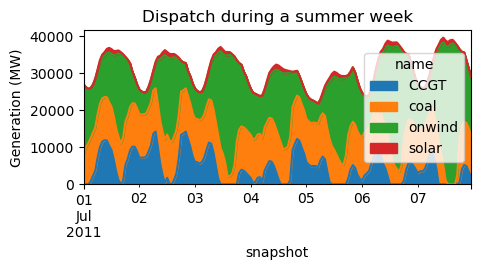

In [324]:
summer = dispatch.loc["2011-07-01":"2011-07-07"]

summer.plot.area(figsize=(5,2))

plt.ylabel("Generation (MW)")
plt.title("Dispatch during a summer week")
plt.show()

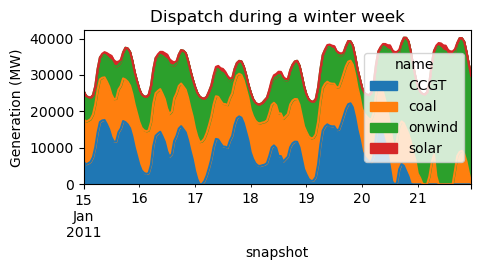

In [325]:
winter = dispatch.loc["2011-01-15":"2011-01-21"]

winter.plot.area(figsize=(5,2))
plt.ylabel("Generation (MW)")
plt.title("Dispatch during a winter week")
plt.show()

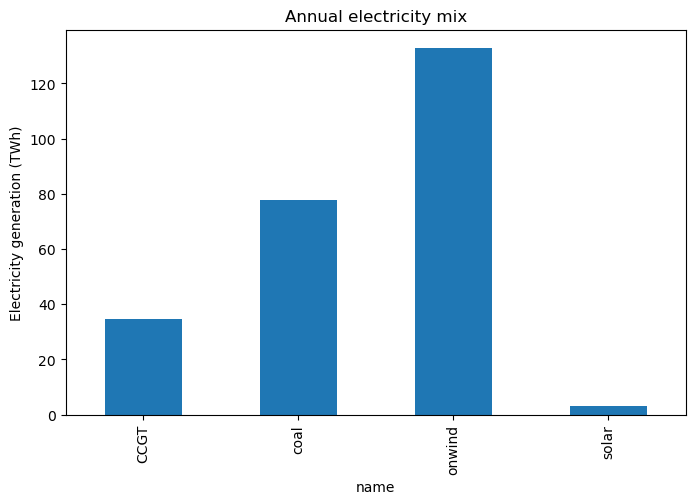

In [326]:
annual_generation = dispatch.sum()
annual_generation_TWh = annual_generation / 1e6
annual_generation_TWh.plot(kind="bar", figsize=(8,5))
plt.ylabel("Electricity generation (TWh)")
plt.title("Annual electricity mix")
plt.show()